# Pedestrian Detection via Spiking Neural Networks (SNNs)

This notebook implements an end-to-end Neuromorphic Machine Learning Operations (NMLOps) pipeline for a single-task Pedestrian Detection problem. Given an image, the objective is to classify the presence of a pedestrian using a Spiking Neural Network (SNN).

## 1. Functional System Setup & Dependencies

Initializes the computational environment by loading fundamental science and deep learning libraries, handling automated fallback installation for neuromorphic tools, and configuring the execution hardware alongside mathematical determinism.

### 1.1 Dynamic Dependency Management

Handles core environment imports and features an automated fallback mechanism to dynamically check, install, and import snntorch and optuna if missing (e.g., when executing for the first time in a cloud-hosted environment like Google Colab).

In [28]:
import os
import sys
import subprocess
import xml.etree.ElementTree as ET
from PIL import Image
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import gc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

try:
    import snntorch as snn
    from snntorch import surrogate
    import optuna  
except ModuleNotFoundError:
    print("Required packages (snntorch/optuna) not found. Environment setup initiated.")
    print("Installing snntorch, optuna and required dependencies...")
    
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "snntorch", "optuna"])
    print("Installation complete. Retrying imports...")
    
    import snntorch as snn
    from snntorch import surrogate
    import optuna

### 1.2 Global Reproducibility & Mathematical Determinism

Enforces global deterministic seeds across Python, NumPy, PyTorch, and CuDNN. It also restricts CUDA/CuBLAS workspace execution behaviors to guarantee absolute mathematical reproducibility across identical execution environments.

In [29]:
use_seed = True

if use_seed:
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # Multi-GPU setup compatibility
    
    # Force PyTorch to use deterministic algorithms
    torch.use_deterministic_algorithms(True)
    
    # Configure CuDNN to maintain strict mathematical consistency
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Reproducibility enabled: global seed set to {seed}.")
else:
    seed = None
    print("Reproducibility disabled: training dynamics might vary across runs.")

Reproducibility enabled: global seed set to 42.


### 1.3 Hardware Acceleration Setup

Detects and assigns the primary execution target (CUDA-enabled GPU or CPU) for tensor operations and network simulations.

In [30]:
if torch.cuda.is_available():
    device = "cuda:0"
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:8"
else:
    device = "cpu"

## 2. Data Repository Deployment & Environment Diagnostics

Initializes the workspace storage layer by identifying the active infrastructure, managing the localized or remote retrieval of the dataset, and performing an atomic diagnostic check on target path directories.

### 2.1 Runtime Environment Detection

Identifies the active runtime host (Google Colab vs. Local WSL/VS Code) to establish the deterministic root path (ROOTDIR_DATA) for all downstream file systems and operational tasks.

In [31]:
if os.path.exists('/content'):
    # Root directory for Google Colab
    ROOTDIR_DATA = "/content"
    print(f"Environment detected: Google Colab.")
else:
    # Root directory for local environment (WSL / VS Code)
    ROOTDIR_DATA = "."
    print(f"Environment detected: Local (WSL).")

Environment detected: Local (WSL).


### 2.2 Cloud-Targeted Dataset Cloning & Workspace Extraction

Automates dataset deployment exclusively when running in Google Colab. If the target data directory is missing from the ephemeral cloud workspace, it clones the remote GitHub repository into a temporary folder, extracts the core dataset to the final destination, and performs a complete cleanup of workspace remnants.

**Note:** For local execution (WSL), this automation is intentionally bypassed, assuming the dataset has already been cloned or structured manually within the local directory root.

In [32]:
REPO_URL = "https://github.com/tmmssd/pedestrian_detection.git"
CLONE_DIR = os.path.join(ROOTDIR_DATA, "repo_temp")
FINAL_DATA_DIR = os.path.join(ROOTDIR_DATA, "data")

if not os.path.exists(FINAL_DATA_DIR):
    print(f"Data folder not found. Downloading dataset from GitHub repository...")
    
    # Remove any corrupted or partial directory remnants from previous attempts
    subprocess.run(["rm", "-rf", CLONE_DIR])
    subprocess.run(["rm", "-rf", FINAL_DATA_DIR])
        
    print("Cloning repository...")
    result = subprocess.run(["git", "clone", REPO_URL, CLONE_DIR], capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"\n[CRITICAL] Git clone failed with exit code {result.returncode}.")
        print(f"Git Error Message:\n{result.stderr}")
        raise RuntimeError("Could not clone the repository. See the Git error message above.")
    
    src_data_path = os.path.join(CLONE_DIR, "data")
    if os.path.exists(src_data_path):
        subprocess.run(["cp", "-r", src_data_path, FINAL_DATA_DIR], check=True)
        print("Dataset successfully downloaded and deployed to /content/data.")
    else:
        raise FileNotFoundError("CRITICAL ERROR: 'data' folder not found inside the cloned repository root.")
            
    # Clean up the temporary workspace directory
    subprocess.run(["rm", "-rf", CLONE_DIR])

### 2.3 Path Mapping & Integrity Diagnostics

Maps the operational dataset subdirectories (train, Pedestrian frame, Pedestrian label) and executes an automated diagnostic routine to assert path existence, structural availability, and total sample count before initializing any dataset loaders.

In [33]:
TRAIN_DIR = os.path.join(ROOTDIR_DATA, "data", "train") 
FRAMES_DIR = os.path.join(TRAIN_DIR, "Pedestrian frame")
LABELS_DIR = os.path.join(TRAIN_DIR, "Pedestrian label")

print("\n--- ENVIRONMENT PATH INTEGRITY DIAGNOSTIC ---")
print(f" -> Is 'TRAIN_DIR' present?  {os.path.exists(TRAIN_DIR)}")
print(f" -> Is 'FRAMES_DIR' present? {os.path.exists(FRAMES_DIR)} ({FRAMES_DIR})")
print(f" -> Is 'LABELS_DIR' present? {os.path.exists(LABELS_DIR)} ({LABELS_DIR})")
if os.path.exists(FRAMES_DIR):
    print(f" -> Found files in frames:   {len(os.listdir(FRAMES_DIR))} items.")


--- ENVIRONMENT PATH INTEGRITY DIAGNOSTIC ---
 -> Is 'TRAIN_DIR' present?  True
 -> Is 'FRAMES_DIR' present? True (./data/train/Pedestrian frame)
 -> Is 'LABELS_DIR' present? True (./data/train/Pedestrian label)
 -> Found files in frames:   4746 items.


## 3. Visual Utility Functions & Performance Diagnostics

Defines a comprehensive suite of plotting utilities divided into neuromorphic-specific behavioral diagnostics (membrane potentials and raster plots) and standard deep learning performance metrics (learning curves and confusion matrices).

### 3.1 Neuromorphic Behavioral Diagnostics

Defines helper functions to inspect the internal, fine-grained state and temporal dynamics of Spiking Neural Networks.

* `plot_leaky`: Tracks individual Leaky Integrate-and-Fire (LIF) membrane potentials (Vmem​) relative to the threshold voltage (Vthr​) across discrete simulation time steps.

* `plot_activity`: Generates a spatial-temporal Raster Plot mapping spiked event outputs across neuron indices alongside the input stimulus current.

In [34]:
def plot_leaky(input_, mem, spk=None, thr=None):
    _, ax1 = plt.subplots(figsize=(8, 4.5))
    ax2 = ax1.twinx()

    ax1.set_xlabel("Time step (a.u.)")
    ax1.set_ylabel("Voltage (a.u.)")
    
    # Track the temporal membrane potential state
    ax1.plot(range(mem.shape[0]), mem.cpu().numpy(), color="tab:green", label="Membrane potential")

    if thr is not None:
        ax1.plot(range(mem.shape[0]), np.ones(mem.shape[0]) * thr, "--", color="tab:blue", label="Threshold voltage")
        min_V = np.min([0, torch.min(mem).numpy(), thr]).item()
        max_V = np.max([torch.max(mem).numpy(), thr]).item()
    else:
        min_V = np.min([0, torch.min(mem).numpy()]).item()
        max_V = torch.max(mem).item()

    ax2.plot(range(mem.shape[0]), input_.cpu().numpy(), color="tab:orange", linewidth=0.9, alpha=0.7, label="Input")
    ax2.set_ylabel("Raw input data (a.u.)", color="tab:orange")

    min_y = np.min([0, min_V, torch.min(input_)])

    if spk is not None:
        # Scale and align spike event markers below the minimum voltage profile
        spk_plot = (-0.05 * abs(max_V - min_y)) * spk.clone().cpu().numpy()
        spk_plot[spk_plot == 0] = np.nan
        ax1.scatter(range(spk.shape[0]), spk_plot, marker="|", s=10, color="tab:red", label="Spike")

    ax2.tick_params(axis='y', which='both', colors="tab:orange", labelcolor="tab:orange")
    ax2.spines['right'].set_color("tab:orange")

    if mem.shape[0] % 2 == 0:
        ax1.set_xticks([0] + np.arange(1, mem.shape[0] + 1, 2).tolist(), [1] + np.arange(2, mem.shape[0] + 1, 2).tolist())
    else:
        ax1.set_xticks(np.arange(0, mem.shape[0] + 1, 2), np.arange(1, mem.shape[0] + 2, 2))
        
    ax1.set_yticks(np.linspace(min_y, max_V * 1.2, 10))
    ax1.set_yticklabels([f"{label:.2f}" for label in np.linspace(min_y, max_V * 1.2, 10)])
    ax1.set_ylim(ymin=min_y - 0.1 * abs(max_V - min_y))
    
    ax2.set_yticks(np.linspace(min_y, torch.max(input_) * 1.2, 10))
    ax2.set_yticklabels([f"{label:.2f}" for label in np.linspace(min_y, torch.max(input_) * 1.2, 10)])
    ax2.set_ylim(ymin=min_y - 0.1 * abs(max_V - min_y) * torch.max(input_) / max_V)
    
    ax1.legend(loc=2)
    ax2.legend(loc=1)
    ax1.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

    if thr is not None:
        print(f"\nThe membrane potential overcame the threshold voltage {np.sum([mem.cpu().numpy() > thr])} time(s).")


def plot_activity(spikes, input_):
    if torch.count_nonzero(spikes) != 0:
        if isinstance(spikes, torch.Tensor):
            spk_plot = spikes.cpu().numpy()
        else:
            spk_plot = np.array(spikes)
            
        if spk_plot.ndim == 3:
            spk_plot = np.squeeze(spk_plot, axis=-1)

        # Convert the dense binary spike matrix into coordinate lists for Address-Event Representation (AER)
        aer = []
        for num, el in enumerate(spk_plot):
            addr = np.where(el)[0].tolist()
            if len(addr) > 0:
                for ii in addr:
                    aer.append([num, ii])
        aer = np.array(aer)

        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()

        ax1.set_xlabel("Time step (a.u.)")
        ax1.set_ylabel("Neuron Index")
        ax1.scatter(aer[:, 0], aer[:, 1] + 1, marker="|", s=35, linewidth=1.5, color="tab:brown", label="Spike", zorder=2)

        ax2.plot(range(input_.shape[0]), input_.cpu().numpy(), color="tab:orange", linewidth=1.2, alpha=0.6, zorder=1, label="Input Current")
        ax2.set_ylabel("Input (a.u.)", color="tab:orange")
        ax2.tick_params(axis='y', which='both', colors="tab:orange", labelcolor="tab:orange")
        ax2.spines['right'].set_color("tab:orange")

        if spikes.shape[0] % 2 == 0:
            ax1.set_xticks([0] + np.arange(1, spk_plot.shape[0] + 1, 2).tolist(), [1] + np.arange(2, spk_plot.shape[0] + 1, 2).tolist())
        else:
            ax1.set_xticks(np.arange(0, spk_plot.shape[0] + 1, 2), np.arange(1, spk_plot.shape[0] + 2, 2))
        
        ax1.set_xlim(-0.5, spk_plot.shape[0] - 0.5)
        ax1.set_ylim(0.5, spk_plot.shape[1] + 0.5)
        
        # Prevent numbers overlapping by spacing the grid dynamically for wide hidden layers
        total_neurons = spk_plot.shape[1]
        if total_neurons > 30:
            tick_step = 20 if total_neurons <= 100 else 50
            y_ticks = [1] + list(range(tick_step, total_neurons + 1, tick_step))
            if total_neurons not in y_ticks:
                y_ticks.append(total_neurons)
        else:
            y_ticks = list(range(1, total_neurons + 1))
            
        ax1.set_yticks(y_ticks)
        ax1.grid(axis='both', alpha=0.15)
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
        
        plt.title("Spiking activity of the hidden LIF layer", fontsize=12, pad=10)
        plt.tight_layout()
        plt.show()
    else:
        print("There is no spiking activity.")

### 3.2 Machine Learning Performance Metrics

Defines standard analytical plotting functions to monitor model optimization stability and single-task evaluation behavior across validation/test epochs.

* `learning_curves`: Generates a side-by-side dual panel tracking loss decay and classification accuracy progression for both Training and Validation splits.

* `draw_confusion_matrix`: Computes and renders a normalized heatmap of the classification confusion matrix to isolate False Positives and False Negatives.

In [35]:
def learning_curves(loss_train_data, loss_val_data, accuracy_train_data, accuracy_val_data):
    _, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axis_label_size = 10
    axis_ticks_size = 9

    # Loss Decay Panel (Left)
    ax = axes[0]
    ax.plot(range(len(loss_train_data)), np.array(loss_train_data), color="#074E37", linestyle='-', linewidth=1.5, label="Training")
    ax.plot(range(len(loss_val_data)), np.array(loss_val_data), color="#E07712", linestyle='-.', linewidth=1.5, label="Validation")
    ax.set_xticks([0] + np.arange(1, len(loss_train_data) + 1, 2).tolist(), [1] + np.arange(2, len(loss_train_data) + 2, 2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Loss", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="upper right")

    # Accuracy Growth Panel (Right)
    ax = axes[1]
    ax.plot(range(len(accuracy_train_data)), 100 * np.array(accuracy_train_data), color="#074E37", linestyle='-', linewidth=1.5, label="Training")
    ax.plot(range(len(accuracy_val_data)), 100 * np.array(accuracy_val_data), color="#E07712", linestyle='-.', linewidth=1.5, label="Validation")
    ax.set_xticks([0] + np.arange(1, len(accuracy_train_data) + 1, 2).tolist(), [1] + np.arange(2, len(accuracy_train_data) + 2, 2).tolist(), fontsize=axis_ticks_size)
    ax.set_xlabel("Epoch", fontsize=axis_label_size)
    ax.set_ylabel("Accuracy (%)", fontsize=axis_label_size)
    ax.grid(axis='both', alpha=0.2)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()


def draw_confusion_matrix(preds, trues, labels):
    # Compute normalized tracking ratios to isolate true detection rates
    cm = confusion_matrix(trues, preds, normalize="true")
    cm_df = pd.DataFrame(cm, index=[ii for ii in labels], columns=[jj for jj in labels])
    
    plt.figure("cm", figsize=(8, 6))
    sn.heatmap(cm_df, annot=True, fmt=".2f", cbar=False, square=False, 
               cmap=LinearSegmentedColormap.from_list("custom_cmap", ["white", "#7C0B2B"]),
               annot_kws={"size": 7, "fontfamily": "serif"})
               
    plt.xlabel("\nPredicted", fontsize=12, fontweight='medium')
    plt.ylabel("True", fontsize=12, fontweight='medium')
    plt.xticks(rotation=0, fontsize=9, fontweight='medium')
    plt.yticks(rotation=0, fontsize=9, fontweight='medium')
    plt.tight_layout()
    plt.show()

## 4. Spatiotemporal Dataset & Custom Data Loaders

Implements data parsing infrastructures and data sequence streaming strategies by establishing a custom single-task representation layer, applying spatial resizing, and building deterministic iterable data subsets.

### 4.1 Custom Dataset Architecture & Target Extraction

Defines the `PedestrianDataset` class inheriting from PyTorch’s base `Dataset`. It implements an atomic `__getitem__` pipeline that loads raw images, parses corresponding XML annotations to verify pedestrian presence, and returns a binary classification label indicating whether a pedestrian is present or absent.

In [36]:
class PedestrianDataset(Dataset):
    def __init__(self, frames_dir, labels_dir, transform=None):
        self.frames_dir = frames_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.filenames = [os.path.splitext(f)[0] for f in os.listdir(frames_dir) if f.endswith(('.jpg', '.png'))]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = os.path.join(self.frames_dir, name + '.jpg')
        if not os.path.exists(img_path):
            img_path = os.path.join(self.frames_dir, name + '.png')
        
        xml_path = os.path.join(self.labels_dir, name + '.xml')
        
        image = Image.open(img_path).convert("L")
        
        # Default targets for background images without pedestrian instances
        label_cls = 0.0
        
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            obj = root.find('object')
            if obj is not None:
                label_cls = 1.0
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label_cls, dtype=torch.float32)

### 4.2 Deterministic Splitting & Iterable Dataloader Channels

Configures image resizing transformations, executes a deterministic train-validation-test split (80% / 10% / 10%) using a dedicated `torch.Generator` seed, and wraps the resulting subsets into optimized, batch-buffered `DataLoader` streams.

In [37]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

full_dataset = PedestrianDataset(FRAMES_DIR, LABELS_DIR, transform=transform)
total_size = len(full_dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

print(f"Total dataset size: {total_size} samples\n")
print(f"Data splitting (%):")
print(f" \tTraining:   {train_size / total_size * 100:.1f}% ({train_size} samples)")
print(f" \tValidation: {val_size / total_size * 100:.1f}% ({val_size} samples)")
print(f" \tTest:       {test_size / total_size * 100:.1f}% ({test_size} samples)\n")

# Enforce deterministic subset sampling via a dedicated generator seed
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 64
workers = min(4, os.cpu_count() or 2)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=workers, pin_memory=True)

Total dataset size: 4746 samples

Data splitting (%):
 	Training:   80.0% (3796 samples)
 	Validation: 10.0% (474 samples)
 	Test:       10.0% (476 samples)



## 5. Integrated Neuromorphic Data Inspection & Ground Truth Alignment

Validates the structural integrity of the pipeline's input layer. Since the dataset is structured to natively provide pre-encoded neuromorphic-ready representations, this exploratory stage visually unpacks a balanced batch of raw sample tensors to confirm that the classification labels remain perfectly aligned across different scenarios.

### 5.1 Balanced Target Anchor Verification

Filters the training partition to isolate indices based on pedestrian presence, extracting a balanced subset containing exactly two positive samples and two negative samples for rigorous comparative diagnostics.

In [38]:
# Separate training dataset indices into positive and negative classes
pos_indices = [i for i in range(len(train_dataset)) if train_dataset[i][1].item() == 1.0]
neg_indices = [i for i in range(len(train_dataset)) if train_dataset[i][1].item() == 0.0]

# Randomly sample exactly two indices from each class to build a balanced subset
selected_pos = np.random.choice(pos_indices, size=2, replace=False)
selected_neg = np.random.choice(neg_indices, size=2, replace=False)

# Combine and shuffle the selected indices to mix the visualization sequence
balanced_indices = np.concatenate([selected_pos, selected_neg])
np.random.shuffle(balanced_indices)

### 5.2 Tensor Spatial Re-Mapping

Iteratively translates the deep learning tensor layout (Channels-First) into standard graphic formats (Channels-Last) for the balanced batch. It programmatically prepares the frames for visual inspection alongside their ground-truth classification status to visually certify data loading accuracy.

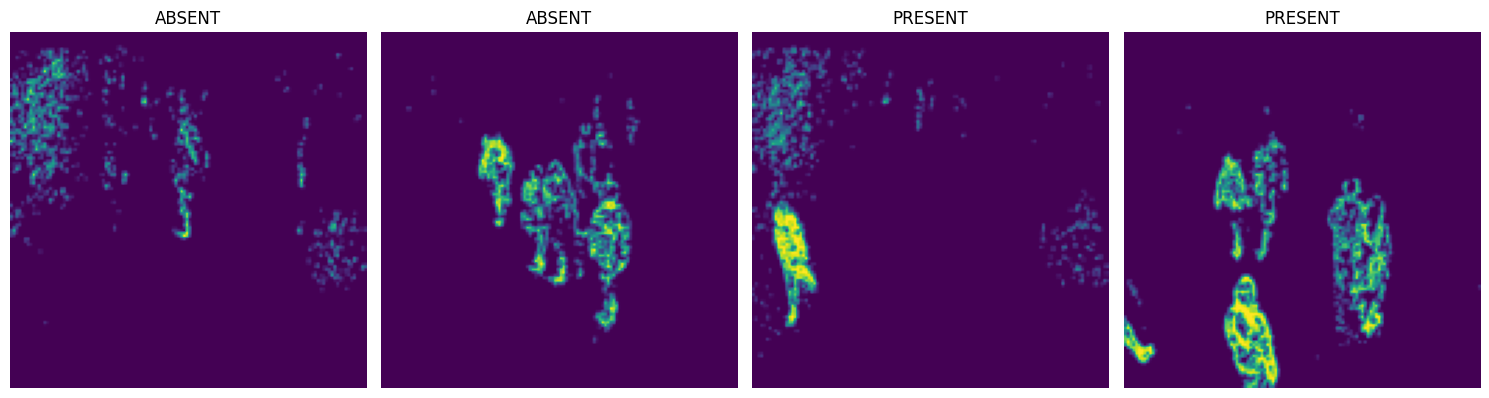

In [39]:
# Configure a single row multi-plot grid for the four balanced samples
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, rnd_idx_raw in zip(axes, balanced_indices):
    rnd_sample = train_dataset[rnd_idx_raw]

    image_tensor = rnd_sample[0].cpu()
    label_cls = rnd_sample[1].cpu().item()

    image_numpy = image_tensor.permute(1, 2, 0).numpy()
    image_numpy = np.clip(image_numpy, 0, 1)

    ax.imshow(image_numpy)

    title_status = "PRESENT" if label_cls == 1.0 else "ABSENT"
    ax.set_title(title_status)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Convolutional Spiking Neural Network (CSNN)

Defines the architectural topology of the Spiking Neural Network designed for simultaneous classification and spatial regression. The network shares a dual convolutional-neuromorphic backbone before branching into distinct task-specific processing heads.

### 6.1 Hyperparameter Dictionary & SNN Execution Constraints

Defines the simulation time frame (T=10), structural filtering resolutions, and Leaky Integrate-and-Fire (LIF) decay factors (β=0.9). Parameters are consolidated into a unified settings dictionary to support modular model instantiation.

In [40]:
# Network parameters and optimization constraints
num_steps = 10              # Time steps for SNN simulation
num_epochs = 5              # Training epochs
learning_rate = 1e-3        # Learning rate for optimizer

# Architectural structural settings
architecture_settings = {
    "input_channels"   : 1,         # Grayscale image input channels
    "input_height"     : 128,       # Height of transformed frame
    "input_width"      : 128,       # Width of transformed frame
    "conv1_filters"    : 16,        # Output feature maps of first layer
    "conv2_filters"    : 32,        # Output feature maps of second layer
    "shared_dim"       : 128,       # Neurons in the common representation layer
    "output_cls_dim"   : 1,         # Binary mapping for pedestrian presence
}

# Neuronal dynamic hyperparameters (snntorch Leaky integration rules)
neuron_settings = {
    "beta"             : 0.9,                # SNN membrane potential decay constant (all layers)
    "threshold"        : 1.0,                # Default voltage threshold value to emit a spike
    "reset_mechanism"  : "zero",         # snntorch default reset mechanism ('zero' or 'subtract')
}

# Put all settings together in a single dictionary for easy access and passing to the model
snn_settings = dict(architecture_settings, **neuron_settings)

### 6.2 CSNN Module Definition & Spatiotemporal Forward Pass

Implements the formal PedestrianSNN class, defining both the topology and its temporal execution:

* Topology (`__init__`): Builds a shared backbone with two Convolutional layers and Max-Pooling stages, using a smooth surrogate gradient (`fast_sigmoid`) for backpropagation. The feature stream then splits into two independent dense heads for Classification.

* Dynamics (`forward`): Unrolls the network state equations sequentially across the simulation time steps (T=10). It tracks and integrates the Leaky Integrate-and-Fire (LIF) membrane potentials (Vmem​), averaging the final output heads' voltages over the entire time window to produce the single-task predictions.

In [41]:
class PedestrianSNN(nn.Module):
    def __init__(self, num_steps, settings):
        super().__init__()
        self.num_steps = num_steps
        
        # Unpacking architectural parameters from the configurations dictionary
        in_channels = settings["input_channels"]
        c1_filters = settings["conv1_filters"]
        c2_filters = settings["conv2_filters"]
        shared_dim = settings["shared_dim"]
        cls_dim = settings["output_cls_dim"]
                
        # Unpacking neuronal dynamic hyperparameters from the configurations dictionary
        beta = settings["beta"]
        
        # Definition of the surrogate gradient to overcome spike non-differentiability
        spike_grad = surrogate.fast_sigmoid()
        
        # Spatial Feature Extraction (Convolutional Layers)
        self.conv1 = nn.Conv2d(in_channels, c1_filters, kernel_size=3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool1 = nn.MaxPool2d(2)
        
        self.conv2 = nn.Conv2d(c1_filters, c2_filters, kernel_size=3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.pool2 = nn.MaxPool2d(2)
        
        # Fully Connected layers for processing decision flows
        # Expected output after pools: 32 feature maps of 32x32 size
        self.fc_shared = nn.Linear(c2_filters * 32 * 32, shared_dim)
        self.lif_shared = snn.Leaky(beta=beta, spike_grad=spike_grad)
        
        # Classification Head (Pedestrian presence)
        self.fc_cls = nn.Linear(shared_dim, cls_dim)
        self.lif_cls = snn.Leaky(beta=beta, spike_grad=spike_grad)
        

    def forward(self, x):
        # Initial reset of internal membrane potentials for SNN components
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem_shared = self.lif_shared.init_leaky()
        mem_cls = self.lif_cls.init_leaky()

        # Accumulators for simulation outputs across time steps
        cls_out_rec = []

        for step in range(self.num_steps):
            # Pass through the first Convolutional + Spiking block
            cur1 = self.pool1(self.conv1(x))
            spk1, mem1 = self.lif1(cur1, mem1)

            # Pass through the second Convolutional + Spiking block
            cur2 = self.pool2(self.conv2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)

            # Flattening for feeding into dense layers
            spk2_flat = spk2.view(spk2.size(0), -1)

            # Shared dense layer
            cur_shared = self.fc_shared(spk2_flat)
            spk_shared, mem_shared = self.lif_shared(cur_shared, mem_shared)

            # Classification output for the current step
            cur_cls = self.fc_cls(spk_shared)
            spk_cls, mem_cls = self.lif_cls(cur_cls, mem_cls)
            cls_out_rec.append(mem_cls)  # Using potential as a continuous value

        # Stack temporal records and average over executed steps
        cls_output = torch.stack(cls_out_rec, dim=0).mean(dim=0).squeeze(-1)

        return cls_output

## 7. Training & Validation Pipeline

Configures the optimization objectives and executes the main iterative training and validation loops to update the network's synaptic weights.

### 7.1 Optimization Loops

Defines the core functional loops (`snn_pedestrian_training_loop` and `snn_pedestrian_val_test_loop`). Both functions handle the single-task classification objective using binary cross-entropy with logits (`BCEWithLogitsLoss`).

In [42]:
def snn_pedestrian_training_loop(data_loader, net, optimizer, criterion_cls, device):
    """
    Single-task training loop for Pedestrian Presence Classification.
    """
    net.train()
    batch_losses = []
    batch_accs = []

    for images, labels_cls in tqdm(data_loader, desc="Training", leave=False):
        images = images.to(device)
        labels_cls = labels_cls.to(device)

        # Forward pass through the network
        pred_cls = net(images)

        # Loss computation
        loss_cls = criterion_cls(pred_cls, labels_cls)
        loss_val = loss_cls
        
        batch_losses.append(loss_val.detach().cpu().item())

        # Training accuracy tracking (Thresholding logits at 0.0 for binary classification)
        preds_binary = (pred_cls >= 0.0).float()
        batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

        # Gradient calculation and synaptic weight updates
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]


def snn_pedestrian_val_test_loop(data_loader, net, criterion_cls, device):
    """
    Validation/testing loop evaluating classification loss and prediction accuracy.
    """
    net.eval()
    batch_losses = []
    batch_accs = []

    with torch.no_grad():
        for images, labels_cls in tqdm(data_loader, desc="Validation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.to(device)

            # Evaluation forward pass
            pred_cls = net(images)

            # Loss computation
            loss_cls = criterion_cls(pred_cls, labels_cls)

            batch_losses.append(loss_cls.detach().cpu().item())

            # Validation accuracy tracking
            preds_binary = (pred_cls >= 0.0).float()
            batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

    epoch_loss = np.mean(batch_losses)
    epoch_acc = np.mean(batch_accs)

    return [epoch_loss, epoch_acc]

### 7.2 Session Initialization & Pipeline Execution

Instantiates the PedestrianSNN architecture on the target hardware device, configures the Adam optimizer, and unrolls the main training execution across the designated epoch horizon while rendering real-time performance curves.

Epoch 1/5: 
	training loss: 0.3883 
	validation loss: 0.3586 
	training accuracy: 83.0084% 
	validation accuracy: 87.9747%


Epoch 2/5: 
	training loss: 0.2881 
	validation loss: 0.3015 
	training accuracy: 89.8841% 
	validation accuracy: 88.6076%


Epoch 3/5: 
	training loss: 0.2562 
	validation loss: 0.2891 
	training accuracy: 91.1222% 
	validation accuracy: 89.4515%


Epoch 4/5: 
	training loss: 0.2364 
	validation loss: 0.2763 
	training accuracy: 91.3593% 
	validation accuracy: 90.0844%


Epoch 5/5: 
	training loss: 0.2208 
	validation loss: 0.2691 
	training accuracy: 91.5701% 
	validation accuracy: 89.4515%


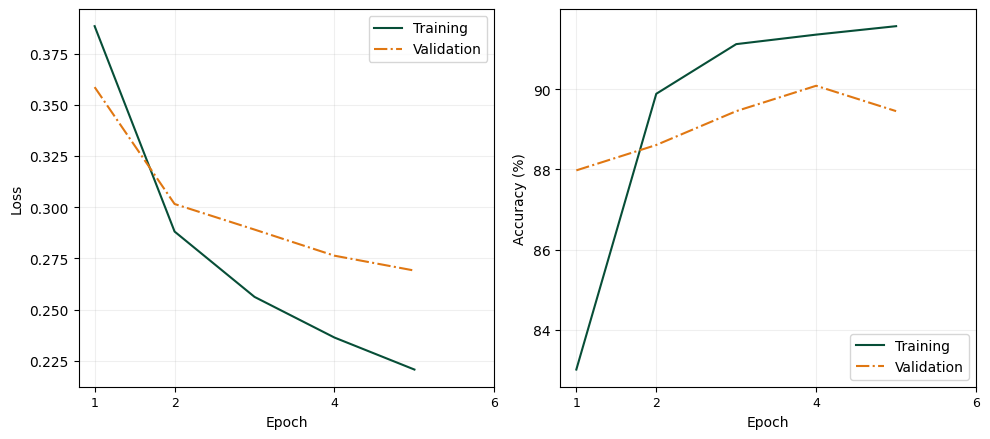

In [43]:
# Force Python garbage collector and clear CUDA cache
gc.collect()
torch.cuda.empty_cache()

# Model initialization passing our unified custom hyperparameter settings
model = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)

# Definition of criteria and optimizer constraints
criterion_cls = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Result collection accumulators for training and validation phases
pedestrian_training_results = []
pedestrian_validation_results = []

# Main execution across the chosen training epochs range
for epoch in range(num_epochs):

    # Execute functional steps for training and validation chunks
    train_loss, train_acc = snn_pedestrian_training_loop(
        train_loader, model, optimizer, criterion_cls, device
    )
    val_loss, val_acc = snn_pedestrian_val_test_loop(
        val_loader, model, criterion_cls, device
    )

    # Append records for history generation
    pedestrian_training_results.append([train_loss, train_acc])
    pedestrian_validation_results.append([val_loss, val_acc])

    # Standard laboratory print output representation format
    print(f"Epoch {epoch+1}/{num_epochs}: \n"
          f"\ttraining loss: {pedestrian_training_results[-1][0]:.4f} \n"
          f"\tvalidation loss: {pedestrian_validation_results[-1][0]:.4f} \n"
          f"\ttraining accuracy: {np.round(pedestrian_training_results[-1][1]*100, 4)}% \n"
          f"\tvalidation accuracy: {np.round(pedestrian_validation_results[-1][1]*100, 4)}%")

# Generate and render the diagnostic learning curves dashboard
learning_curves(
    np.array(pedestrian_training_results)[:, 0],    # training loss
    np.array(pedestrian_validation_results)[:, 0],  # validation loss
    np.array(pedestrian_training_results)[:, 1],    # training accuracy
    np.array(pedestrian_validation_results)[:, 1]   # validation accuracy
)

## 8. Neuromorphic State Inspection & Diagnostic Tracking

Unrolls the temporal execution of the trained SNN to extract, log, and visualize internal bio-inspired dynamics that are usually masked during standard deep learning forward passes.

### 8.1 Temporal State Logging (Inference Unrolling)

Performs evaluation-mode inference on a single validation batch. By manually replicating the temporal loop, it tracks and logs the step-by-step internal membrane potentials (Vmem​), output spike events, and input synaptic currents from the hidden shared layer (lif_shared).

In [44]:
data_iter = iter(val_loader)
images, labels_cls = next(data_iter)

# Isolate the primary sample and enforce evaluation mode
sample_image = images[0].unsqueeze(0).to(device) 
model.eval()

with torch.no_grad():
    mem1 = model.lif1.init_leaky()
    mem2 = model.lif2.init_leaky()
    mem_shared = model.lif_shared.init_leaky()
    
    membrane_pot_log = []
    spikes_log = []
    input_current_accum = []
    
    # Unroll the forward loop across the configured simulation time horizon
    for step in range(model.num_steps):
        cur1 = model.pool1(model.conv1(sample_image))
        spk1, mem1 = model.lif1(cur1, mem1)
        
        cur2 = model.pool2(model.conv2(spk1))
        spk2, mem2 = model.lif2(cur2, mem2)
        
        spk2_flat = spk2.view(spk2.size(0), -1)
        
        cur_shared = model.fc_shared(spk2_flat)
        spk_shared, mem_shared = model.lif_shared(cur_shared, mem_shared)
        
        # Log states stripping the batch dimension to focus on the single sample
        membrane_pot_log.append(mem_shared[0].detach().cpu())
        spikes_log.append(spk_shared[0].detach().cpu())
        input_current_accum.append(cur_shared[0].detach().cpu())

membrane_pot_tensor = torch.stack(membrane_pot_log)
spikes_tensor = torch.stack(spikes_log)
input_current_tensor = torch.stack(input_current_accum)

### 8.2 Single-Neuron Voltage Dynamics & Layer Raster Plot

Utilizes the custom visualization tools to inspect the recorded neuromorphic tracks:

* Single-Neuron Tracking: Maps the voltage charging and discharging phases of a specific hidden neuron relative to its execution threshold.

* Collective Population Tracking: Generates a spatiotemporal Raster Plot to map the sparse spiking distribution of the entire layer across the execution time frame.

Rendering plot_leaky for Shared Layer Neuron 0:


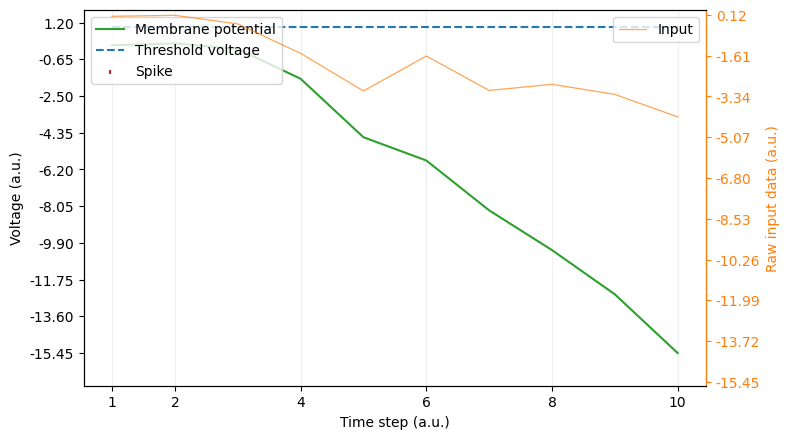


The membrane potential overcame the threshold voltage 0 time(s).

Rendering plot_activity (Raster Plot of the Layer's Spiking Activity):


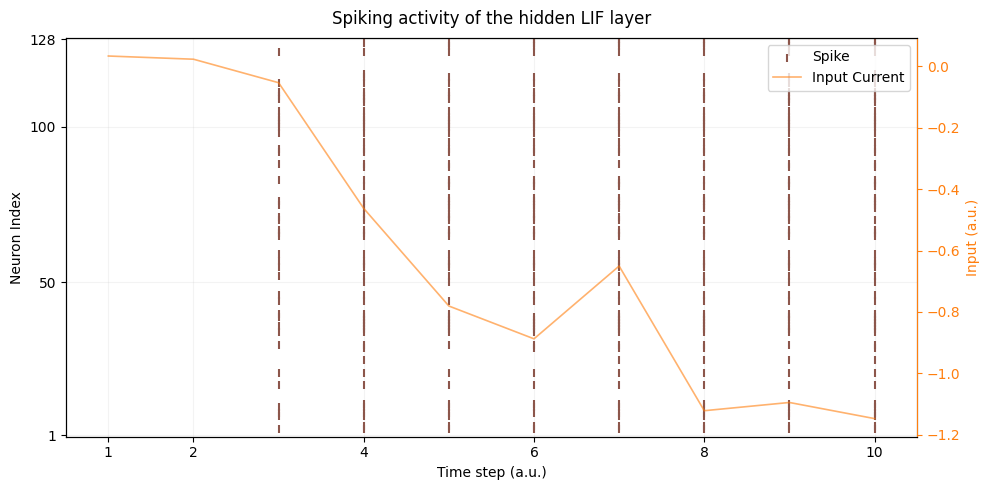

In [45]:
target_neuron_idx = 0

print(f"Rendering plot_leaky for Shared Layer Neuron {target_neuron_idx}:")
plot_leaky(
    input_=input_current_tensor[:, target_neuron_idx], 
    mem=membrane_pot_tensor[:, target_neuron_idx], 
    spk=spikes_tensor[:, target_neuron_idx], 
    thr=1.0 
)

print("\nRendering plot_activity (Raster Plot of the Layer's Spiking Activity):")
plot_activity(
    spikes=spikes_tensor, 
    input_=input_current_tensor.mean(dim=1) 
)

## 9. Model Performance Evaluation & Test Metrics

Defines validation and localization metrics required to assess the network's behavior on the independent test split, followed by the formal execution of the final inference session.

### 9.1 Testing Analytics

Implements the core evaluation algorithms to quantify prediction accuracy:

* `calculate_iou`: Computes the geometric Intersection over Union (IoU) ratio between predicted and ground-truth bounding boxes.

* `test_model_accuracy`: Iterates through the test loader, converts continuous classification outputs into binary flags via logit-thresholding (0.0), accumulates matching predictions, and tracks spatial overlap scores before rendering a normalized confusion matrix heatmap.

In [46]:
def test_model_accuracy(model, test_loader, device):
    model.eval()
    correct_cls = 0
    total_images = 0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for images, labels_cls in test_loader:
            images = images.to(device)
            labels_cls = labels_cls.cpu()

            pred_cls = model(images).cpu()
            preds_binary = (pred_cls >= 0.0).float()

            correct_cls += (preds_binary == labels_cls).sum().item()
            total_images += images.size(0)

            all_preds.extend(preds_binary.numpy())
            all_trues.extend(labels_cls.numpy())

    cls_accuracy = (correct_cls / total_images) * 100
    print(f"Pedestrian Presence Accuracy: {cls_accuracy:.2f}%")

    draw_confusion_matrix(np.array(all_preds), np.array(all_trues), ["Absent", "Present"])
    return cls_accuracy


### 9.2 Inference Session & Evaluation Execution

Launches the evaluation routine over the independent test split to output the global performance diagnostics and visualize class-level error distributions.

Pedestrian Presence Accuracy: 91.18%


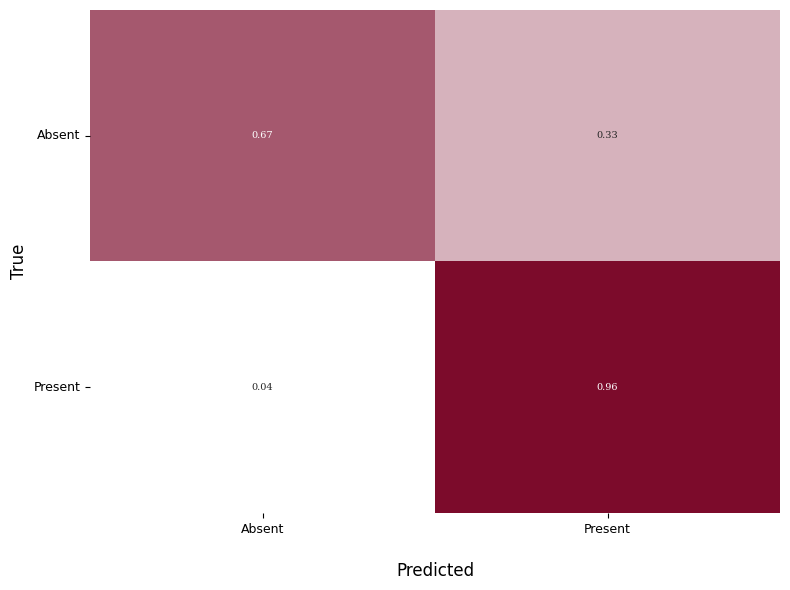

91.17647058823529

In [47]:
test_model_accuracy(model, test_loader, device)

## 10. AutoML - Hyperparameter Optimization (HPO) with Optuna

Integrates an automated machine learning framework to dynamically sample network parameters, optimize single-task performance via Tree-structured Parzen Estimators (TPE), and execute comprehensive final model diagnostics.

### 10.1 Diagnostic Test Loop & Statistical Baseline

Defines the `snn_pedestrian_test_evaluation_loop` function to execute rigorous post-training verification. Beyond multi-task loss and geometric True Positive IoU tracking, it computes the Statistical Chance Level based on the test split's majoritarian class distribution to establish a mathematical performance baseline.

In [48]:
def snn_pedestrian_test_evaluation_loop(test_loader, net, device, draw_matrix=True):
    net.eval()
    correct_cls = 0
    total_images = 0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for images, labels_cls in tqdm(test_loader, desc="Testing Evaluation", leave=False):
            images = images.to(device)
            labels_cls = labels_cls.cpu()

            pred_cls = net(images).cpu()
            preds_binary = (pred_cls >= 0.0).float()

            correct_cls += (preds_binary == labels_cls).sum().item()
            total_images += images.size(0)
            all_preds.extend(preds_binary.numpy())
            all_trues.extend(labels_cls.numpy())

    cls_accuracy = (correct_cls / total_images) * 100
    _, counts = np.unique(np.array(all_trues), return_counts=True)
    chance_level = (counts.max() / len(all_trues)) * 100

    if draw_matrix:
        draw_confusion_matrix(np.array(all_preds), np.array(all_trues), ["Absent", "Present"])

    return [cls_accuracy, chance_level]


### 10.2 Dynamic Search Space Exploration (Optuna Study)

Configures and launches the hyperparameter optimization study over an expanded search space. The framework dynamically samples architectural configurations (shared_dim), temporal unrolling depth (num_steps), optimization parameters (lr, weight_decay), and neuromorphic dynamic properties (beta, threshold) via a Tree-structured Parzen Estimator (TPE) sampler. Instead of focusing on a single metric, the optimization maximizes a validation score that rewards classification accuracy while simultaneously penalizing bounding box regression instabilities, avoiding gradient conflicts.

In [49]:
def snn_pedestrian_training_loop_hpo(data_loader, net, optimizer, criterion_cls, device):
    net.train()
    batch_losses = []
    batch_accs = []
    for images, labels_cls in data_loader:
        images = images.to(device)
        labels_cls = labels_cls.to(device)

        pred_cls = net(images)
        loss_cls = criterion_cls(pred_cls, labels_cls)
        loss_val = loss_cls
        batch_losses.append(loss_val.detach().cpu().item())

        preds_binary = (pred_cls >= 0.0).float()
        batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()
    return [np.mean(batch_losses), np.mean(batch_accs)]


def snn_pedestrian_val_loop_hpo(data_loader, net, criterion_cls, device):
    net.eval()
    batch_losses = []
    batch_accs = []

    with torch.no_grad():
        for images, labels_cls in data_loader:
            images = images.to(device)
            labels_cls = labels_cls.to(device)

            pred_cls = net(images)

            loss_cls = criterion_cls(pred_cls, labels_cls)
            loss_val = loss_cls

            batch_losses.append(loss_val.detach().cpu().item())

            preds_binary = (pred_cls >= 0.0).float()
            batch_accs.extend((preds_binary == labels_cls).detach().cpu().numpy())

    return [np.mean(batch_losses), np.mean(batch_accs)]


def objective(trial: optuna.Trial, device=device) -> float:
    """
    Returns validation accuracy for HPO experiments through Optuna on PedestrianSNN.
    """
    # Define the search space dynamically updating our unified settings dictionary
    snn_settings["shared_dim"] = trial.suggest_int("shared_dim", 128, 512, step=128)
    snn_settings["beta"]       = trial.suggest_float("beta", 0.70, 0.99, step=0.05)
    lr                         = trial.suggest_float("lr", 5e-5, 1e-3, log=True)
    snn_settings["threshold"]  = trial.suggest_float("threshold", 0.8, 1.5, step=0.1)
    num_steps                  = trial.suggest_int("num_steps", 8, 24, step=4)
    weight_decay               = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # Re-instantiate the model dynamically with the trial settings
    model = PedestrianSNN(num_steps=num_steps, settings=snn_settings).to(device)

    criterion_cls = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    pedestrian_validation_results = []

    for epoch in range(N_EPOCHS_HPO):
        _ = snn_pedestrian_training_loop_hpo(
            train_loader, model, optimizer, criterion_cls, device
        )
        val_loss, val_acc = snn_pedestrian_val_loop_hpo(
            val_loader, model, criterion_cls, device
        )
        pedestrian_validation_results.append([val_loss, val_acc])

        print(f"Trial {trial.number} | Epoch {epoch+1}/{N_EPOCHS_HPO}: "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    # Extracts final results for balanced score calculation
    final_loss, final_acc = pedestrian_validation_results[-1]
    
    # Calculate the combined score: Maximize accuracy by penalizing explosive losses
    custom_score = final_acc - (0.05 * final_loss)

    return custom_score # Return val_loss for optimization


N_TRIALS = 10
N_EPOCHS_HPO = 5
SEED_HPO = 42

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}\n")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED_HPO),
    study_name="NMLOps_Pedestrian_HPO"
)

print(f"Running {N_TRIALS} Optuna trials ({N_EPOCHS_HPO} epochs each)...\n")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# Summary of best trial
best = study.best_trial
print(f"\n{'='*55}")
print(f"  Best trial: #{best.number}")
print(f"  Validation Balanced Score: {best.value:.4f}")
print(f"  Optimal hyperparameters found:")
for k, v in best.params.items():
    print(f"    {k:<15} = {v}")
print(f"{'='*55}\n")

[I 2026-06-16 17:45:28,224] A new study created in memory with name: NMLOps_Pedestrian_HPO


Train batches: 60
Validation batches: 8
Test batches: 8

Running 10 Optuna trials (5 epochs each)...



  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_16658/1260971861.py:52: UserWarning: The distribution is specified by [0.7, 0.99] and step=0.05, but the range is not divisible by `step`. It will be replaced with [0.7, 0.95].
  snn_settings["beta"]       = trial.suggest_float("beta", 0.70, 0.99, step=0.05)


Trial 0 | Epoch 1/5: Val Loss: 0.3634 | Val Acc: 89.45%
Trial 0 | Epoch 2/5: Val Loss: 0.3263 | Val Acc: 89.03%
Trial 0 | Epoch 3/5: Val Loss: 0.2998 | Val Acc: 89.24%
Trial 0 | Epoch 4/5: Val Loss: 0.2756 | Val Acc: 90.08%
Trial 0 | Epoch 5/5: Val Loss: 0.2760 | Val Acc: 90.08%
[I 2026-06-16 17:46:01,371] Trial 0 finished with value: 0.8870462116262706 and parameters: {'shared_dim': 256, 'beta': 0.95, 'lr': 0.0004480392682684062, 'threshold': 1.2000000000000002, 'num_steps': 8, 'weight_decay': 2.9375384576328313e-06}. Best is trial 0 with value: 0.8870462116262706.
Trial 1 | Epoch 1/5: Val Loss: 0.4101 | Val Acc: 82.70%
Trial 1 | Epoch 2/5: Val Loss: 0.3445 | Val Acc: 87.76%
Trial 1 | Epoch 3/5: Val Loss: 0.3315 | Val Acc: 89.24%
Trial 1 | Epoch 4/5: Val Loss: 0.3161 | Val Acc: 89.24%
Trial 1 | Epoch 5/5: Val Loss: 0.3061 | Val Acc: 88.82%
[I 2026-06-16 17:46:32,587] Trial 1 finished with value: 0.8728819310531524 and parameters: {'shared_dim': 128, 'beta': 0.95, 'lr': 0.0003027182927

### 10.3 Optimal Network Convergence (Full Retraining)

Extracts the optimal parameter configuration discovered during the HPO phase to instantiate a fresh network topology. It executes a full-scale retraining session over an extended horizon (20 epochs) to guarantee synaptic weight convergence before generating the diagnostic learning histories.

Retraining the best configuration for 20 epochs.



Epoch 1/20: 
	training loss: 0.3869 
	validation loss: 0.3701 
	training accuracy: 84.9842% 
	validation accuracy: 88.8186%


Epoch 2/20: 
	training loss: 0.2953 
	validation loss: 0.3362 
	training accuracy: 90.2002% 
	validation accuracy: 89.6624%


Epoch 3/20: 
	training loss: 0.2605 
	validation loss: 0.3070 
	training accuracy: 91.333% 
	validation accuracy: 90.0844%


Epoch 4/20: 
	training loss: 0.2352 
	validation loss: 0.2867 
	training accuracy: 91.5437% 
	validation accuracy: 89.8734%


...

Epoch 16/20: 
	training loss: 0.0882 
	validation loss: 0.2879 
	training accuracy: 96.9705% 
	validation accuracy: 90.2954%


Epoch 17/20: 
	training loss: 0.0804 
	validation loss: 0.2965 
	training accuracy: 97.0759% 
	validation accuracy: 90.0844%


Epoch 18/20: 
	training loss: 0.0678 
	validation loss: 0.3058 
	training accuracy: 97.8398% 
	validation accuracy: 90.2954%


Epoch 19/20: 
	training loss: 0.0609 
	validation loss: 0.3145 
	training accuracy: 98.3404% 
	validation accuracy: 89.2405%


Epoch 20/20: 
	training loss: 0.0535 
	validation loss: 0.3192 
	training accuracy: 98.4457% 
	validation accuracy: 89.4515%


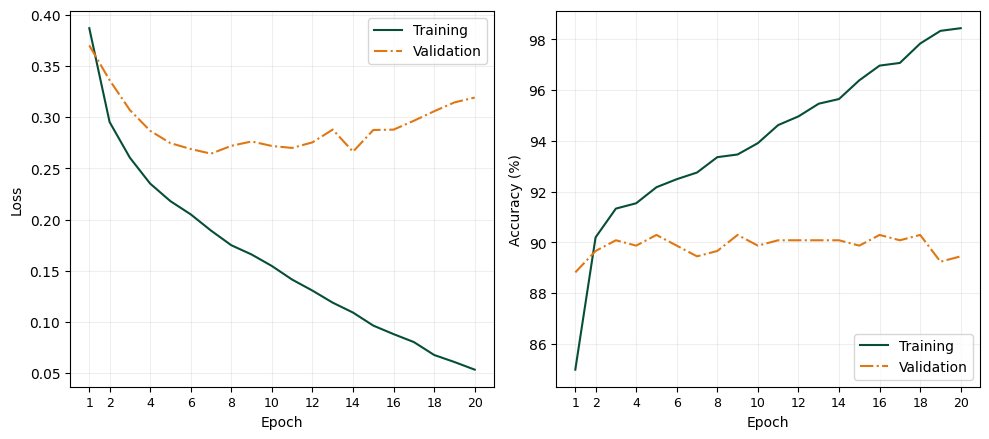

In [50]:
snn_settings["shared_dim"] = best.params["shared_dim"]
snn_settings["beta"]       = best.params["beta"]
snn_settings["threshold"]  = best.params["threshold"]
optimal_num_steps = best.params["num_steps"]
optimal_pedestrian_net = PedestrianSNN(num_steps=optimal_num_steps, settings=snn_settings).to(device)

FULL_EPOCHS = 20
print(f"Retraining the best configuration for {FULL_EPOCHS} epochs.\n")

criterion_cls = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(optimal_pedestrian_net.parameters(), lr=best.params["lr"], weight_decay=best.params["weight_decay"])

pedestrian_training_results = []
pedestrian_validation_results = []

for epoch in range(FULL_EPOCHS):
    train_loss, train_acc = snn_pedestrian_training_loop(
        train_loader, optimal_pedestrian_net, optimizer, criterion_cls, device
    )
    val_loss, val_acc = snn_pedestrian_val_test_loop(
        val_loader, optimal_pedestrian_net, criterion_cls, device
    )

    pedestrian_training_results.append([train_loss, train_acc])
    pedestrian_validation_results.append([val_loss, val_acc])

    print(f"Epoch {epoch+1}/{FULL_EPOCHS}: \n"
          f"\ttraining loss: {pedestrian_training_results[-1][0]:.4f} \n"
          f"\tvalidation loss: {pedestrian_validation_results[-1][0]:.4f} \n"
          f"\ttraining accuracy: {np.round(pedestrian_training_results[-1][1]*100,4)}% \n"
          f"\tvalidation accuracy: {np.round(pedestrian_validation_results[-1][1]*100,4)}%")

# Generate performance graphs
learning_curves(
    np.array(pedestrian_training_results)[:,0],    # training loss
    np.array(pedestrian_validation_results)[:,0],  # validation loss
    np.array(pedestrian_training_results)[:,1],    # training accuracy
    np.array(pedestrian_validation_results)[:,1]   # validation accuracy
)

### 10.4 Optimized Baseline Verification

Launches the final verification protocol on the fully converged, optimized model using the independent test split. This acts as the final benchmark to measure the single-task model's generalization capabilities in prediction accuracy.

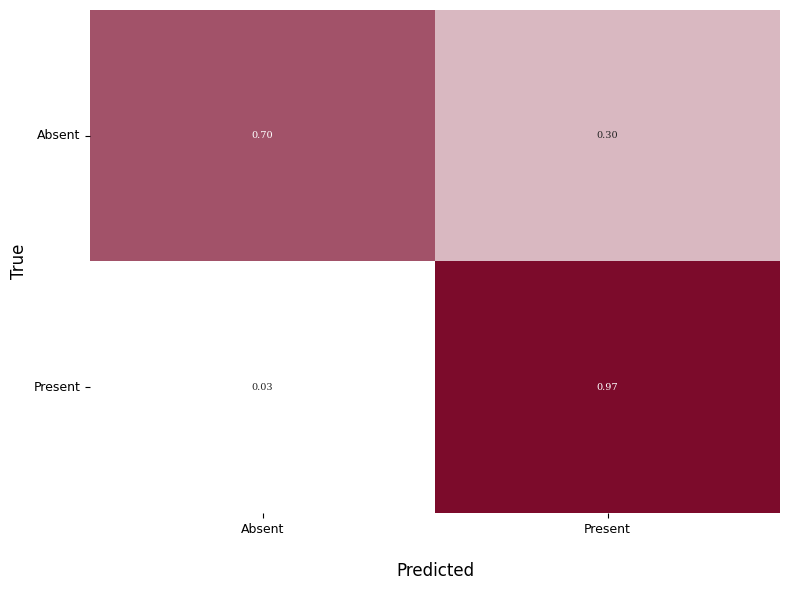


HPO Final Result Summary:
   -> Optimized Test Accuracy : 92.2269%
   -> Test Chance Level : 83.4034%


In [51]:
final_test_results = snn_pedestrian_test_evaluation_loop(
    test_loader, optimal_pedestrian_net, device, draw_matrix=True
)

print("\nHPO Final Result Summary:")
print(f"   -> Optimized Test Accuracy : {np.round(final_test_results[0], 4)}%")
print(f"   -> Test Chance Level : {np.round(final_test_results[1], 4)}%")

### 10.5 Qualitative Verification & Prediction Mirroring

Implements a visual validation pipeline on the test split to assess the model's classification capabilities. By randomly sampling unseen images, this section overlays the ground truth annotations (solid green boundaries) against the network's spatiotemporal multi-task predictions (dashed red boundaries). This qualitative mirroring serves as a diagnostic tool in the NMLOps workflow to visually segregate precise bounding box tight-fitting from spatial degradation effects, false positives, or class misalignments.

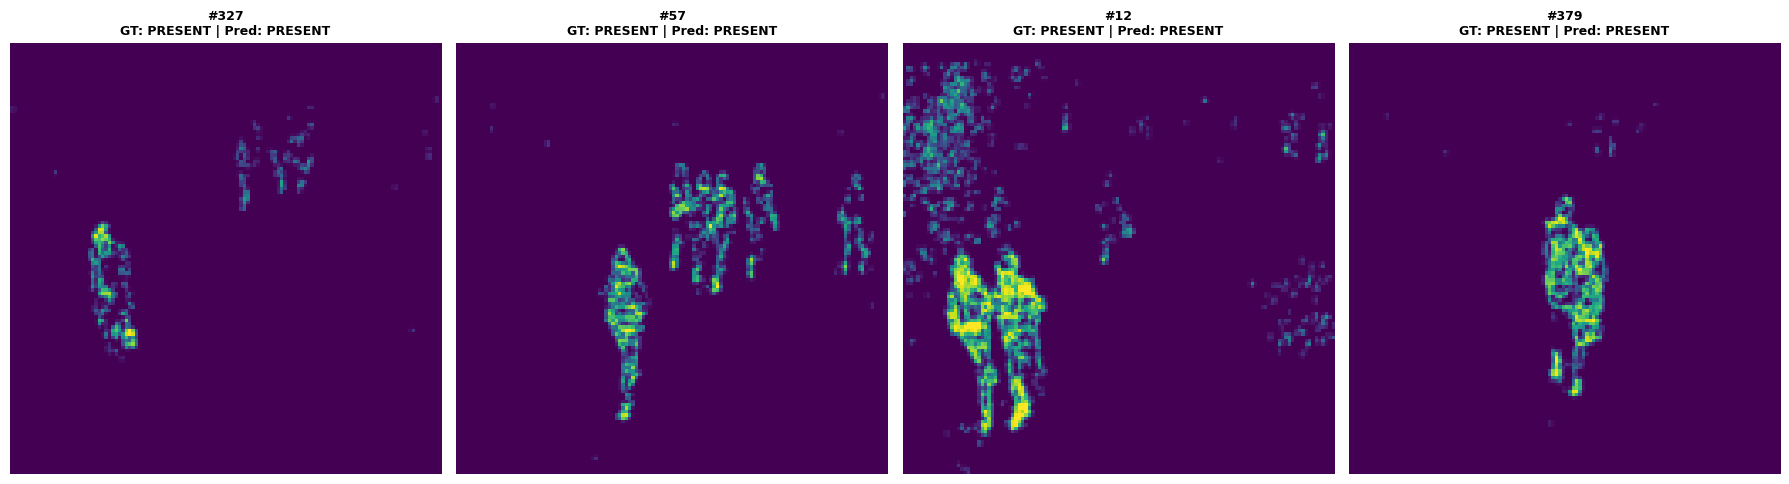

In [52]:
# Select four random samples from the test split for qualitative verification
test_indices = random.sample(range(len(test_dataset)), 4)
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
optimal_pedestrian_net.eval()

with torch.no_grad():
    for ax, rnd_idx in zip(axes, test_indices):
        image_tensor, label_cls_gt = test_dataset[rnd_idx]
        image_tensor = image_tensor.to(device)

        pred_cls_raw = optimal_pedestrian_net(image_tensor.unsqueeze(0))
        pred_cls = 1.0 if pred_cls_raw.cpu().item() >= 0.0 else 0.0

        image_numpy = image_tensor.cpu().permute(1, 2, 0).numpy()
        ax.imshow(np.clip(image_numpy, 0, 1))

        gt_status = 'PRESENT' if label_cls_gt.item() == 1.0 else 'ABSENT'
        pred_status = 'PRESENT' if pred_cls == 1.0 else 'ABSENT'
        ax.set_title(f'#{rnd_idx}\nGT: {gt_status} | Pred: {pred_status}', fontsize=9, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()
